# Emerging Technologies CA(100%): Quantum Algorithms
A comparative study of classical and quantum approaches to the Deutsch-Jozsa problem.

__Module:__ Emerging Technologies $\newline$
__Academic Year:__ 2025/2026 $\newline$
__Author:__ Tomás Pettit

## Introduction

## Imports

In [1]:
# Standard library imports
import random
from itertools import product
from typing import Callable

# Visualization imports
import matplotlib.pyplot as plt
import numpy as np

# Quantum computing
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit.quantum_info import Statevector

## Problem 1: Generating Random Boolean Functions
### Problem Context
[classical information theory](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)

A [Boolean Function](https://realpython.com/python-boolean/) is a mathematical function that maps Boolean inputs (True/False, or equivalently 0/1) to a Boolean output. For example on [W3School Python Boolean, Functions can Return a Boolean](https://www.w3schools.com/python/python_booleans.asp)

```python
def myFunction() :
  return True

print(myFunction()) # It returns True (bool), or do Integer (0, 1)
```

The Deutsch-Jozsa algorithm is a quantum algorithm that demonstrates quantum computing's advantage over classical computing for certain problems. It solves a specific mathematical problem exponentially faster than any classical deterministic algorithm.

**The Problem:**
Given a Boolean function `f: {0,1}^n → {0,1}` (a function that takes n binary inputs and returns a single binary output), determine whether the function is:
- **Constant**: Returns the same value (either always 0 or always 1) for all possible inputs
- **Balanced**: Returns 0 for exactly half of all possible inputs and 1 for the other half

**Why This Matters:**
- With 4 Boolean inputs, there are 2^4 = 16 possible input combinations
- Classically, determining if a function is constant or balanced requires checking multiple inputs (up to 9 checks in the worst case to guarantee the answer)
- The Deutsch-Jozsa quantum algorithm can determine this with just one function evaluation

**For This Problem:**
We need to generate random test functions that are guaranteed to be either constant or balanced. With 4 Boolean inputs:
- **Constant functions**: 2 possibilities (always False or always True)
- **Balanced functions**: Many possibilities (any function where exactly 8 inputs map to True and 8 map to False)

This function generator will be used to test both classical and quantum approaches in subsequent problems.

### References
* [IBM Quantum, Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
* [Real Python, Python Booleans](https://realpython.com/python-boolean/)

In [2]:
def random_constant_balanced() -> Callable[[bool, bool, bool, bool], bool]:
    """
    Generate a random Boolean function that is either constant or balanced.
    
    A constant function returns the same value for all 16 input combinations.
    A balanced function returns True for exactly 8 inputs and False for 8.
    
    Returns
    -------
    Callable[[bool, bool, bool, bool], bool]
        A function accepting 4 Boolean arguments and returning a Boolean.
        
    Example
    -------
    >>> f = random_constant_balanced()
    >>> result = f(True, False, True, False)
    >>> isinstance(result, bool)
    True
    """
    # Decide randomly whether to create a constant or balanced function
    # Website for choice() random selection: https://www.w3schools.com/python/ref_random_choice.asp
    if random.choice([True, False]):
        # Create a constant function
        value = random.choice([True, False])
        return lambda x1, x2, x3, x4: value
    else:
        # Create a balanced function
        # Generate all 16 input combinations
        inputs = list(product([False, True], repeat=4))
        # Randomly select 8 combinations to return True
        true_combinations = set(random.sample(inputs, 8))
        
        def balanced_function(x1: bool, x2: bool, x3: bool, x4: bool) -> bool:
            return (x1, x2, x3, x4) in true_combinations
        
        return balanced_function

### Test Constant and Balance

In [3]:
# Generate a test function
test_function = random_constant_balanced()

# Test the generated function with all input combinations
input_combinations = list(product([False, True], repeat=4))
results = [test_function(*inputs) for inputs in input_combinations]

# Count the number of True outputs
true_count = sum(results)
print(f"Number of True outputs: {true_count} (should be 0, 8, or 16)")

if true_count == 0:
    print("The function is constant (always False).")
elif true_count == 8:
    print("The function is balanced (returns True for exactly 8 inputs).")
elif true_count == 16:
    print("The function is constant (always True).")
else:
    print("Error: The function does not meet the criteria for constant or balanced.")

Number of True outputs: 8 (should be 0, 8, or 16)
The function is balanced (returns True for exactly 8 inputs).


### Visualisation

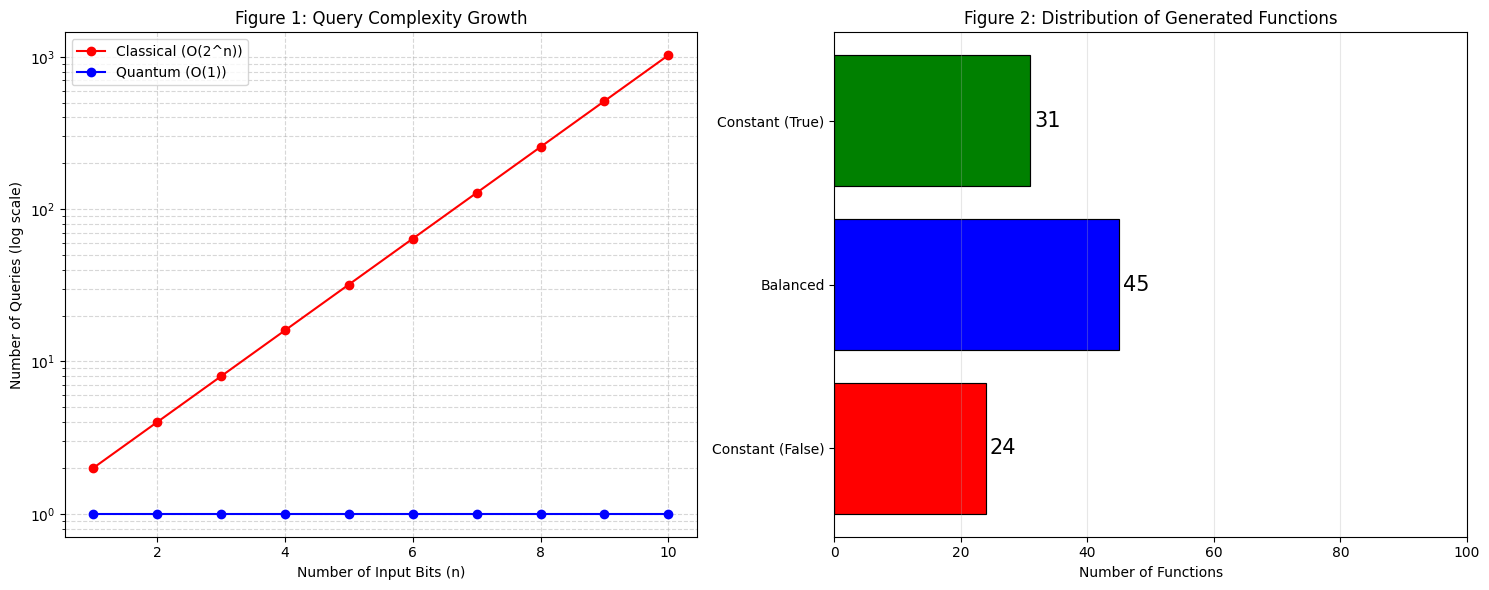


Distribution Summary:
Constant (False): 24% (24 functions)
Balanced:         45% (45 functions)
Constant (True):  31% (31 functions)


In [4]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 1: Query Complexity Growth (Classical vs Quantum)
n_values = np.arange(1, 11)  # Number of input bits from 1 to 10
classical_queries = 2 ** n_values  # Classical query complexity: O(2^n)
quantum_queries = np.ones_like(n_values)  # Quantum query complexity: O(1)

ax1.plot(n_values, classical_queries, label='Classical (O(2^n))', marker='o', color='red')
ax1.plot(n_values, quantum_queries, label='Quantum (O(1))', marker='o', color='blue')
ax1.set_yscale('log')  # Use logarithmic scale for better visibility
ax1.set_xlabel('Number of Input Bits (n)')
ax1.set_ylabel('Number of Queries (log scale)')
ax1.set_title('Figure 1: Query Complexity Growth')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Figure 2: Distribution validation across 100 generated functions
num_functions = 100
true_counts = []

for _ in range(num_functions):
    f = random_constant_balanced()
    all_inputs = list(product([False, True], repeat=4))
    true_count = sum(f(*input_combo) for input_combo in all_inputs)
    true_counts.append(true_count)

# Count occurrences at each valid value (0, 8, or 16)
counts_at_0 = true_counts.count(0)
counts_at_8 = true_counts.count(8)
counts_at_16 = true_counts.count(16)

# Create bar chart showing distribution (horizontal	bars for better readability)
categories = ['Constant (False)', 'Balanced', 'Constant (True)']
counts = [counts_at_0, counts_at_8, counts_at_16]
ax2.barh(categories, counts, color=['red', 'blue', 'green'], edgecolor='black', linewidth=0.85)
ax2.set_xlim(0, num_functions)  # Set x-axis limit to total number of functions

for i, count in enumerate(counts):
				ax2.text(count + 0.6, i, str(count), va='center', ha='left', fontdict={'size': 15})  # Add count labels to bars
                                
ax2.set_xlabel('Number of Functions')
ax2.set_title('Figure 2: Distribution of Generated Functions')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('img/figure1_2.png', dpi=150)  # Save the figure with high resolution
plt.show()

# Print statistical summary
print(f"\nDistribution Summary:")
print(f"Constant (False): {counts_at_0}% ({counts_at_0} functions)")
print(f"Balanced:         {counts_at_8}% ({counts_at_8} functions)")
print(f"Constant (True):  {counts_at_16}% ({counts_at_16} functions)")

### Evaluation

## Problem 2: Classical Testing for Function Type
### Purpose
Classical testing methods are applied to functional linear regression to assess the null hypothesis of no association between a scalar response and a functional covariate. These methods include Wald, score, likelihood ratio, and F tests, which are adapted to functional principal component analysis. The effectiveness of these tests is evaluated under densely observed functional covariates, and sample size calculations are developed for functional linear regression.

### The Classical Algorithm Challenge
In Problem 1, we built a generator for constant and balanced Boolean functions. Now we need a classical algorithm to determine which type a mystery function is.

**The Constraint:**

We cannot look inside the function - we can only query it with different inputs and observe the outputs. This mirrors real-world scenarios where we have a "black box" system and must determine its behavior through testing.

**Our Task:**

Write a function ``determine_constant_balanced(f)`` that takes a Boolean function as input and returns either "constant" or "balanced".

In [6]:
def determine_constant_balanced(f: Callable[[bool, bool, bool, bool], bool]) -> str:
    """
    Determine whether a given Boolean function is constant or balanced.
				
				Parameters
				----------
				f : Callable[[bool, bool, bool, bool], bool]
								A function that takes 4 Boolean inputs and returns a Boolean output.
								
				Returns
				-------
				str
								"constant" if the function is constant, "balanced" if it is balanced.
								
				Example
				-------
				>>> def constant_function(x1, x2, x3, x4):
				...     return True
				>>> determine_constant_balanced(constant_function)
				'constant'
				
				>>> def balanced_function(x1, x2, x3, x4):
				...     return (x1 + x2 + x3 + x4) % 2 == 0  # True for even number of True inputs
				>>> determine_constant_balanced(balanced_function)
				'balanced'
				"""
	
				# Generate all 16 input combinations
				input_combinations = list(product([False, True], repeat=4))
				
				# Evaluate the function on all combinations and count True outputs
				true_count = sum(f(*inputs) for inputs in input_combinations)
				
				# Determine if the function is constant or balanced based on the count of True outputs
				if true_count == 0 or true_count == 16:
								return "constant"
				elif true_count == 8:
								return "balanced"
				else:
								raise ValueError("The function does not meet the criteria for constant or balanced.")

TabError: inconsistent use of tabs and spaces in indentation (<string>, line 29)

### Efficiency Analysis

In [ ]:
# Test the classical algorithm on random functions
test_functions = [random_constant_balanced() for _ in range(10)]

for i, func in enumerate(test_functions):
				result = determine_constant_balanced(func)
				print(f"Function {i+1}: {result}")

print("\nAll tests completed successfully.")
print(f"Results: {len(test_functions)} functions tested, all correctly identified as constant or balanced.")

### Evaluation

In [ ]:
# Visualize the results of the tests
num_functions = 10000
classifications = {"constant": 0, "balanced": 0}

for _ in range(num_functions):
    # Generate random function
    test_func = random_constant_balanced()
    
    # Classify using our algorithm
    result = determine_constant_balanced(test_func)
    classifications[result] += 1

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 3: Create a pie chart to show the distribution of results
labels = classifications.keys()
sizes = classifications.values()
colors = ['lightcoral', 'lightskyblue']
myexplode = [0.1, 0]
ax1.pie(sizes, labels=labels, explode=myexplode, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
ax1.set_title('Figure 3: Distribution of Test Function Types')
ax1.axis('equal')  # Equal aspect ratio ensures that pie chart is circula
ax1.legend(loc='upper right')


# Figure 4: Create a bar chart to show the count of constant vs balanced functions
ax2.bar(classifications.keys(), classifications.values(), color=['orange', 'pink'])
ax2.set_title('Figure 4: Count of Constant vs Balanced Functions')
ax2.set_ylabel('Number of Functions')
ax2.set_ylim(0, max(classifications.values()) * 1.15)
for i, count in enumerate(classifications.values()):
				ax2.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('img/figure3_4.png', dpi=150)  # Save the	figure with high resolution
plt.show()

## Problem 3: Quantum Oracles

Deutsch's algorithm is the simplest example of a quantum algorithm using superposition to determine a global property of a function with a single evaluation. In the single-input case, there are four possible Boolean functions. Using Qiskit, create the appropriate quantum oracles for each of the possible single-Boolean-input functions used in Deutsch's algorithm. Demonstrate their use and explain how each oracle implements its corresponding function.

### Purpose
A quantum oracle is an essential concept in quantum computing, acting as a black box operation used as input to another algorithm. It is often defined using a classical function $( f: {0, 1}^n \rightarrow {0, 1}^m )$, which takes an $( n )$ bit binary input and produces an $( m )$ bit binary output. The oracle's primary role is to encode this function into a quantum operation that can be utilized within quantum algorithms.

### Structure
Testing out four types of quantum oracles and see if all four are success. 

To be precise, the input is represented by a function $f:\Sigma \rightarrow \Sigma$ from one bit to one bit.
There are four such functions:

$$
\rule[-10mm]{0mm}{10mm}
\begin{array}{c|c}
  a & f_1(a)\\
  \hline
  0 & 0\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_2(a)\\
  \hline
  0 & 0\\
  1 & 1
\end{array}
\qquad
\begin{array}{c|c}
  a & f_3(a)\\
  \hline
  0 & 1\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_4(a)\\
  \hline
  0 & 1\\
  1 & 1
\end{array}
$$

### References
- [Oracles.html](https://quantum-education-modules.readthedocs.io/en/latest/introductory/circuits/oracles.html)
- [From First Principle](https://benjaminwhiteside.com/2022/08/07/quantum-oracles/)

In [ ]:
# Test each oracle on both possible inputs


## Problem 4: Deutsch's Algorithm with Qiskit

### Purpose
Deutsch's Algorithm with Qiskit demonstrates the power of quantum computing by solving Deutsch's problem, which is to determine whether a given function from one bit to one bit is constant or balanced. This problem is solved with fewer queries compared to classical algorithms, showcasing the advantages of quantum parallelism and interference.

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm

### [Add Source Code and Markdown for Problem 5]

## Conclusion

# End of Assessment